# Chapter 6: Element-wise Operations

Element-wise add (eWiseAdd) computes union, element-wise multiply (eWiseMult) computes intersection.

In [1]:
import graphblas as gb
from graphblas import Matrix, binary
import networkx as nx
import matplotlib.pyplot as plt
from graph_utils import draw_graph, draw_comparison, matrix_to_graph, draw_matrix

## Two Graphs

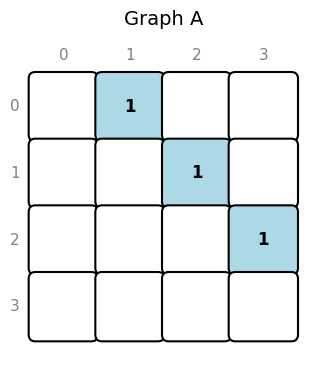

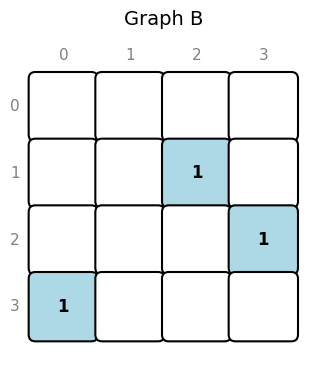

<Axes: title={'center': 'Graph B'}>

In [2]:
# Graph A: social network
edges_A = [(0,1), (1,2), (2,3)]
A = Matrix.from_coo(
    [e[0] for e in edges_A], [e[1] for e in edges_A],
    [1]*len(edges_A), nrows=4, ncols=4, dtype=int
)

# Graph B: different relationship
edges_B = [(1,2), (2,3), (3,0)]
B = Matrix.from_coo(
    [e[0] for e in edges_B], [e[1] for e in edges_B],
    [1]*len(edges_B), nrows=4, ncols=4, dtype=int
)

draw_matrix(A, title="Graph A")
draw_matrix(B, title="Graph B")

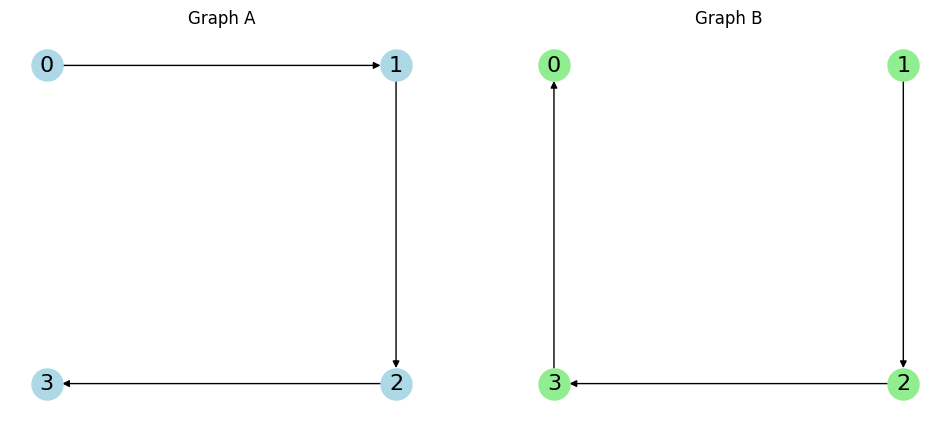

{0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (0, 0)}

In [3]:
pos = {0: (0,1), 1: (1,1), 2: (1,0), 3: (0,0)}
G_A = nx.DiGraph(edges_A)
G_B = nx.DiGraph(edges_B)

draw_comparison(
    [G_A, G_B],
    ["Graph A", "Graph B"],
    pos=pos,
    colors=['lightblue', 'lightgreen']
)

## Union (eWiseAdd)

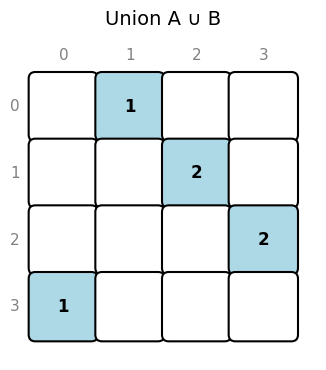

<Axes: title={'center': 'Union A ∪ B'}>

In [4]:
# Union: edge exists if in A OR B
union = A.ewise_add(B, binary.plus).new()
draw_matrix(union, title="Union A ∪ B")

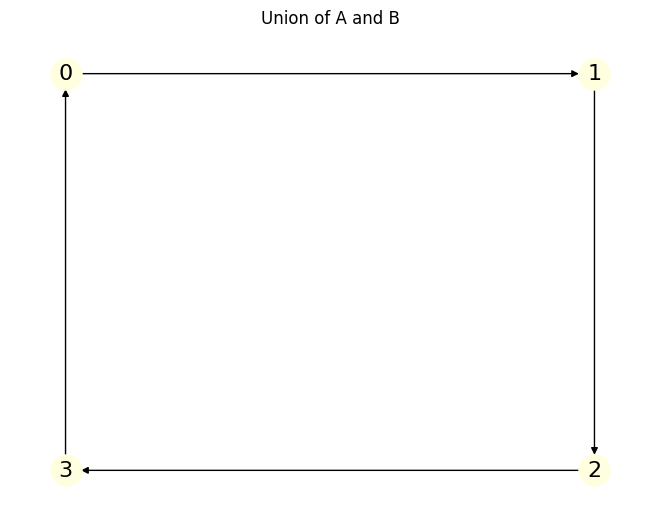

{0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (0, 0)}

In [5]:
# Visualize union
G_union = matrix_to_graph(union)
draw_graph(G_union, pos=pos, title="Union of A and B", node_color='lightyellow')

## Intersection (eWiseMult)

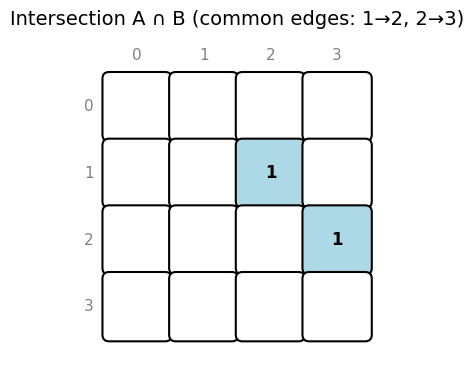

<Axes: title={'center': 'Intersection A ∩ B (common edges: 1→2, 2→3)'}>

In [6]:
# Intersection: edge exists if in A AND B
intersection = A.ewise_mult(B, binary.times).new()
draw_matrix(intersection, title="Intersection A ∩ B (common edges: 1→2, 2→3)")

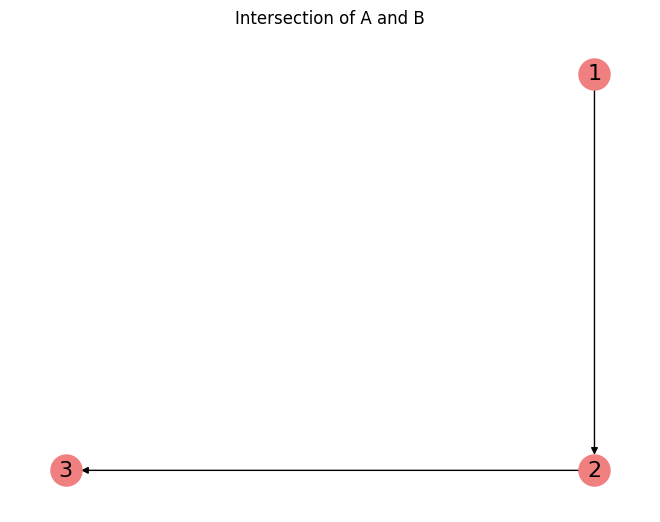

Common edges: 1->2 and 2->3


In [7]:
# Visualize intersection
G_int = matrix_to_graph(intersection)
draw_graph(G_int, pos=pos, title="Intersection of A and B", node_color='lightcoral')
print("Common edges: 1->2 and 2->3")

## Filtering by Threshold

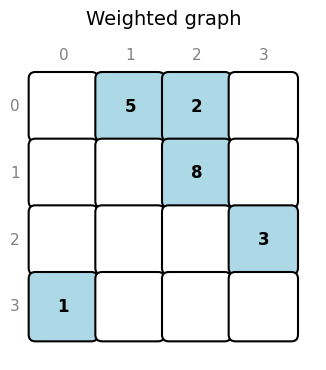

<Axes: title={'center': 'Weighted graph'}>

In [8]:
# Weighted graph
W = Matrix.from_coo(
    [0, 0, 1, 2, 3], [1, 2, 2, 3, 0],
    [5, 2, 8, 3, 1], nrows=4, ncols=4, dtype=int
)
draw_matrix(W, title="Weighted graph")

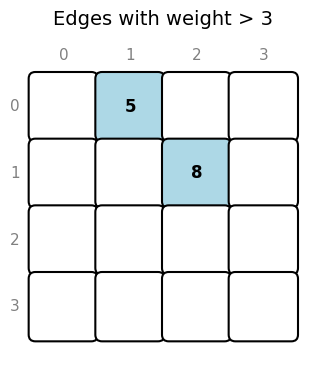

<Axes: title={'center': 'Edges with weight > 3'}>

In [9]:
# Keep only edges with weight > 3
threshold = 3
filtered = W.select(">", threshold).new()
draw_matrix(filtered, title=f"Edges with weight > {threshold}")

## Apply Operations

Apply operations transform matrix values element-wise using unary or binary operators with a scalar.

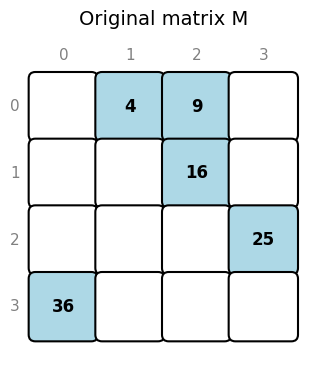

<Axes: title={'center': 'Original matrix M'}>

In [10]:
# Sparse matrix with random float values
from graphblas import unary
M = Matrix.from_coo(
    [0, 0, 1, 2, 3], [1, 2, 2, 3, 0],
    [4.0, 9.0, 16.0, 25.0, 36.0], nrows=4, ncols=4, dtype=float
)
draw_matrix(M, title="Original matrix M")

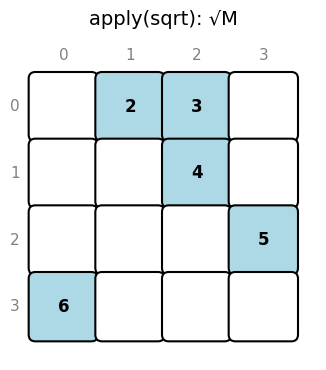

<Axes: title={'center': 'apply(sqrt): √M'}>

In [11]:
# apply(): apply a unary operator to each element
# Take the square root of each value
sqrt_M = M.apply(unary.sqrt).new()
draw_matrix(sqrt_M, title="apply(sqrt): √M")

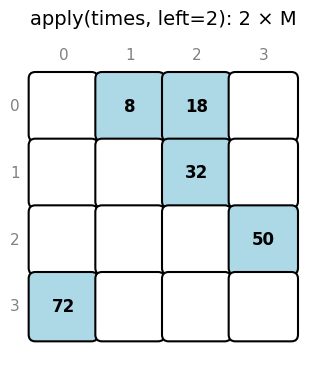

<Axes: title={'center': 'apply(times, left=2): 2 × M'}>

In [12]:
# apply_first(): binary op with scalar on left, matrix on right
# Compute 2 * M (scalar is first/left operand)
doubled = M.apply(binary.times, left=2).new()
draw_matrix(doubled, title="apply(times, left=2): 2 × M")

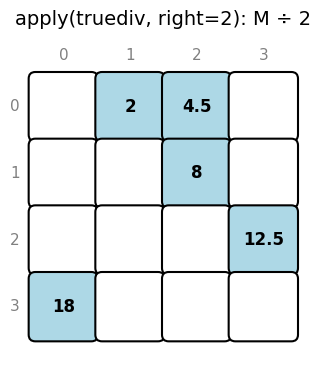

<Axes: title={'center': 'apply(truediv, right=2): M ÷ 2'}>

In [13]:
# apply_second(): binary op with matrix on left, scalar on right
# Compute M / 2 (scalar is second/right operand)
halved = M.apply(binary.truediv, right=2).new()
draw_matrix(halved, title="apply(truediv, right=2): M ÷ 2")